#                              **AI4005: Mini Project**
##                      **ANN parameterized GMM Clustering Algorithm**
### Anirudh Srinivasan (CS20BTECH11059) | Ajit Shankar (ES20BTECH11003)

## Importing Libraries and dependencies

In [ ]:
!pip install deap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 1.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Creating Synthetic Dataset

### Initiating the points  randomly to clusters

In [ ]:
# Create a synthetic dataset with 3 clusters
# X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

### Assuming an underlying gaussian distribution for input data

In [ ]:
# Set the mean and covariance
mean1 = [0, 0]
mean2 = [2, 0]
cov1 = [[1, .7], [.7, 1]]
cov2 = [[.5, .4], [.4, .5]]

# Generate data from the mean and covariance
data1 = np.random.multivariate_normal(mean1, cov1, size=1000) # Here data1 has the X and Y coordinates of the generated points
data2 = np.random.multivariate_normal(mean2, cov2, size=1000)

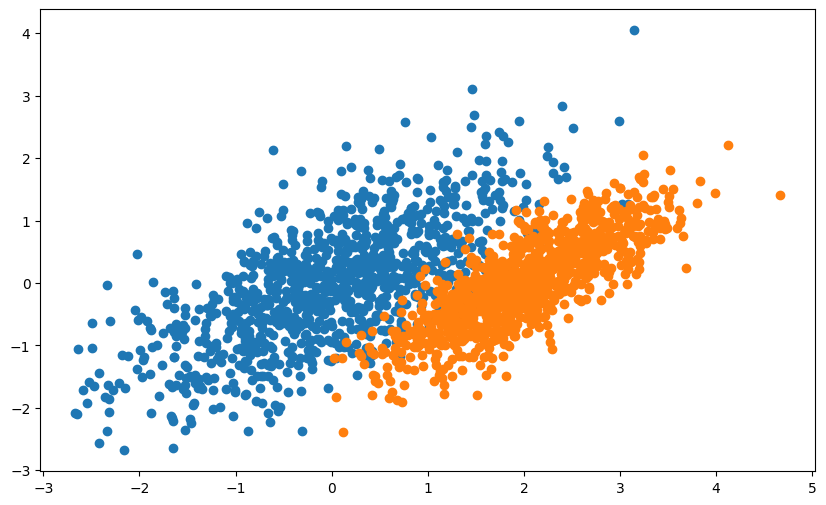

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(data1[:,0],data1[:,1])
plt.scatter(data2[:,0],data2[:,1])

# sns.kdeplot(data1, color='red', linewidth=2, levels=20, linestyle='-', alpha=0.7)
# sns.kdeplot(data2, color='blue', linewidth=2, levels=20, linestyle='-', alpha=0.7)


plt.grid(False)
plt.show()

In [ ]:
data = np.concatenate((data1, data2), axis=0)

# Generate labels for each data point
y_true = np.concatenate((np.zeros(data1.shape[0]), np.ones(data2.shape[0])))

# Shuffle the data and labels simultaneously
data, y_true = shuffle(data, y_true, random_state=42)

y_true = y_true.astype(int)

# Separate features (X) from labels (y_true)
X = data

## Building Model

In [ ]:
# Define the neural network architecture
def build_model(input_dim, hidden_units, n_components):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(input_dim,)))
    for units in hidden_units:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    # Output layer: mean vector and covariance matrix parameters for each component
    # For simplicity, we'll assume diagonal covariance matrices
    output_size = n_components * (input_dim + input_dim)  # means + variances
    model.add(tf.keras.layers.Dense(output_size, activation=None))
    return model

In [ ]:
# Custom loss function for GMM
def gmm_loss(y_true, y_pred):
    # Reshape y_pred to separate components' parameters
    means = tf.reshape(y_pred[:, :n_components * input_dim], (-1, n_components, input_dim))
    log_vars = tf.reshape(y_pred[:, n_components * input_dim:], (-1, n_components, input_dim))
    vars = tf.exp(log_vars)

    # Compute the log likelihood of each point under each Gaussian component
    y_true_expanded = tf.expand_dims(y_true, 1)
    diff = y_true_expanded - means
    exponent = tf.reduce_sum(((diff ** 2) / vars), axis=2)
    log_prob = -0.5 * (exponent + tf.reduce_sum(log_vars, axis=2) + input_dim * tf.math.log(2 * np.pi))

    # Logsumexp trick for numerical stability
    max_log_prob = tf.reduce_max(log_prob, axis=1, keepdims=True)
    log_prob = log_prob - max_log_prob
    log_sum_exp = max_log_prob[:, 0] + tf.math.log(tf.reduce_sum(tf.exp(log_prob), axis=1))

    # Negative log likelihood
    loss = -tf.reduce_mean(log_sum_exp)
    return loss

## Running Model

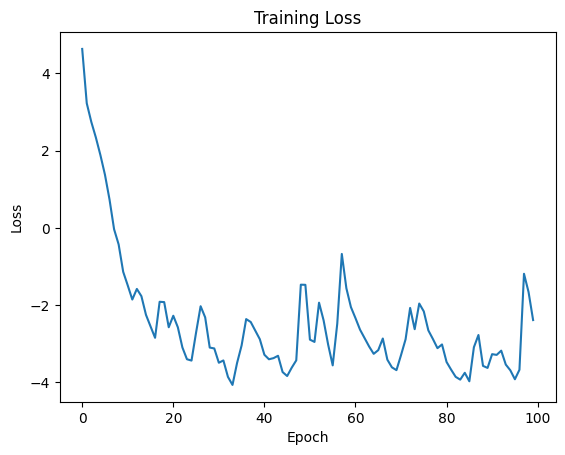

10/10 [==============================] - 0s 3ms/step
Silhouette Score (ANN-parameterized GMM): 0.2581009097450038
Silhouette Score (Vanilla GMM): 0.6596332095691734


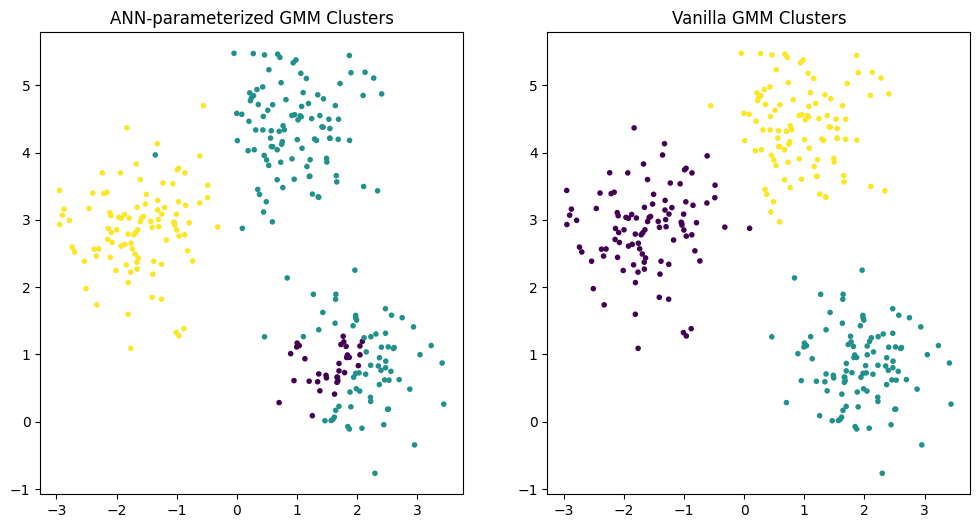

In [ ]:
# Instantiate the model
input_dim = X.shape[1]
n_components = 3
model = build_model(input_dim=input_dim, hidden_units=[64, 64], n_components=n_components)

# Compile the model with the custom loss function
model.compile(optimizer='adam', loss=gmm_loss)

# Train the model
history = model.fit(X, X, epochs=100, verbose=0)  # y_true is not used, so we can pass X as a dummy

# Plot the training loss
plt.plot(history.history['loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Evaluate the model using silhouette score
y_pred = model.predict(X)
means = y_pred[:, :n_components * input_dim].reshape(-1, n_components, input_dim)
assignments = np.argmin(np.linalg.norm(X[:, np.newaxis] - means, axis=2), axis=1)
silhouette_ann = silhouette_score(X, assignments)

# Compare with vanilla GMM
gmm = GaussianMixture(n_components=3, random_state=0).fit(X)
gmm_assignments = gmm.predict(X)
silhouette_vanilla = silhouette_score(X, gmm_assignments)

# Print silhouette scores
print(f'Silhouette Score (ANN-parameterized GMM): {silhouette_ann}')
print(f'Silhouette Score (Vanilla GMM): {silhouette_vanilla}')

# Plot the clusters
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=assignments, cmap='viridis', marker='.')
plt.title('ANN-parameterized GMM Clusters')

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=gmm_assignments, cmap='viridis', marker='.')
plt.title('Vanilla GMM Clusters')
plt.show()

- Implementing a full Gaussian Mixture Model (GMM) with a neural network that parameterizes any covariance matrix (not just diagonal) is significantly more complex. This is because the covariance matrices must remain positive semi-definite during optimization, which is a non-trivial constraint.

- To ensure that the covariance matrices are positive semi-definite, one common approach is to parameterize the Cholesky decomposition of the covariance matrix. The Cholesky decomposition is a decomposition of a Hermitian, positive-definite matrix into the product of a lower triangular matrix and its conjugate transpose.

## Generalized GMM implementation (without diagonal covariance matrix assumption)

In [ ]:
# Function to reconstruct the lower triangular matrix from the network output
def reconstruct_lower_triangular_matrix(params, input_dim):
    # Initialize an empty matrix
    L = tf.zeros((params.shape[0], input_dim, input_dim), dtype=tf.float32)

    # Indices for the lower triangular part of the matrix
    indices = tf.concat([tf.expand_dims(tf.range(input_dim), 1),
                         tf.expand_dims(tf.range(input_dim), 1)], axis=1)
    indices = tf.linalg.band_part(indices, -1, 0)

    # Fill in the lower triangular part with the parameters
    updates = tf.map_fn(lambda x: tf.gather(x, indices), params)
    L = tf.tensor_scatter_nd_update(L, indices, updates)

    return L

# Custom loss function for GMM with any covariance matrix
def gmm_loss(y_true, y_pred):
    # Extract mean vectors and Cholesky decomposition parameters from y_pred
    means = y_pred[:, :input_dim]
    chol_params = y_pred[:, input_dim:]

    # Reconstruct the lower triangular matrix L from chol_params
    L = reconstruct_lower_triangular_matrix(chol_params, input_dim)

    # Compute the covariance matrix as L * L^T
    covariance_matrix = tf.matmul(L, tf.transpose(L, perm=[0, 2, 1]))

    # Compute the Mahalanobis distance
    diff = tf.expand_dims(y_true - means, -1)
    inv_covariance_matrix = tf.linalg.inv(covariance_matrix)
    mahalanobis_distance = tf.matmul(tf.matmul(tf.transpose(diff, perm=[0, 2, 1]), inv_covariance_matrix), diff)
    mahalanobis_distance = tf.squeeze(mahalanobis_distance, -1)

    # Compute the log likelihood
    log_likelihood = -0.5 * (mahalanobis_distance + tf.math.log(tf.linalg.det(covariance_matrix)) + input_dim * tf.math.log(2 * np.pi))

    # Negative log likelihood loss
    loss = -tf.reduce_mean(log_likelihood)
    return loss

In [ ]:
# Define the neural network architecture
def build_model_gen(input_dim, hidden_units, n_clusters):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(input_dim,)))
    for units in hidden_units:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    # Output layer: mean vector and covariance matrix parameters for each cluster
    # For simplicity, we'll assume diagonal covariance matrices
    output_size = n_clusters * (input_dim + input_dim * (input_dim + 1) / 2)  # means + variances
    model.add(tf.keras.layers.Dense(output_size, activation=None))
    return model

The output dimension is calculated as such as for each cluster the mean and covariance matrix must be predicted. The size of these vectors/ matrices will depend only on the input dimension size

### Mahalanobis distance
The Mahalanobis distance is a measure of the distance between a point and a distribution. For a multivariate normal distribution, it is defined as:

$$ D_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})} $$

where:

- $\mathbf{x}$ is the data point.
- $\boldsymbol{\mu}$ is the mean of the distribution.
- $\mathbf{\Sigma}$ is the covariance matrix of the distribution.
- $\mathbf{\Sigma}^{-1}$ is the inverse of the covariance matrix.

The Mahalanobis distance accounts for the correlation between variables and is scale-invariant, meaning it doesn't depend on the scale of measurements.

### Log Likelihood of a Multivariate Normal Distribution

The probability density function (PDF) for a multivariate normal distribution is given by:

$$ f(\mathbf{x} | \boldsymbol{\mu}, \mathbf{\Sigma}) = \frac{1}{\sqrt{(2\pi)^k |\mathbf{\Sigma}|}} \exp\left(-\frac{1}{2} D_M(\mathbf{x})^2\right) $$

where:

- $k$ is the number of dimensions.
- $|\mathbf{\Sigma}|$ is the determinant of the covariance matrix.

The log likelihood of observing a data point $\mathbf{x}$ given the parameters of the distribution is the natural logarithm of the PDF:

$$ \log f(\mathbf{x} | \boldsymbol{\mu}, \mathbf{\Sigma}) = -\frac{1}{2} \left( k \log(2\pi) + \log|\mathbf{\Sigma}| + D_M(\mathbf{x})^2 \right) $$

### Negative Log Likelihood Loss

In the context of training a model, we want to minimize the negative log likelihood, which is equivalent to maximizing the log likelihood. The negative log likelihood loss for a single data point is:

$$ \mathcal{L}(\mathbf{x}) = -\log f(\mathbf{x} | \boldsymbol{\mu}, \mathbf{\Sigma}) $$

For a dataset with $N$ points, the total negative log likelihood loss is the sum of the individual losses:

$$ \mathcal{L}(\mathbf{X}) = -\sum_{i=1}^{N} \log f(\mathbf{x}_i | \boldsymbol{\mu}, \mathbf{\Sigma}) $$

### Implementation in gmm_loss

In the `gmm_loss` function, the following steps are performed:

1. Extract Mean and Cholesky Parameters: The mean vector and the parameters for the Cholesky decomposition of the covariance matrix are extracted from the neural network's output.
2. Reconstruct Covariance Matrix: The lower triangular matrix ($L$) is reconstructed from the Cholesky parameters, and the covariance matrix $\mathbf{\Sigma}$ is computed as $LL^T$.
3. Compute Mahalanobis Distance: The Mahalanobis distance is computed for each data point. In the code, this is done by calculating $(\mathbf{x} - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})$, which is the squared Mahalanobis distance.
4. Compute Log Likelihood: The log likelihood is computed using the formula given above. The determinant of the covariance matrix and the Mahalanobis distance are used here.
5. Negative Log Likelihood Loss: The negative of the mean log likelihood across all data points is computed to form the loss function. This is what the model will attempt to minimize during training.

By minimizing this loss, the neural network learns to output parameters ($\boldsymbol{\mu}$ and $\mathbf{\Sigma}$) that maximize the likelihood of the data under the assumed Gaussian distribution, effectively fitting a GMM to the data.